# LSTM vs. MLP on EGX30

This notebook repeats the Day 1 return-prediction setup on the real EGX30 index, while swapping in an LSTM.

The goal is to compare the two architectures honestly: same market series, same lagged-return features, same target, same chronological train/test split, same evaluation window.

Readings:
- https://medium.com/data-science/illustrated-guide-to-lstms-and-gru-s-a-step-by-step-explanation-44e9eb85bf21
- https://colah.github.io/posts/2015-08-Understanding-LSTMs


In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')


In [10]:
repo_root = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'data' / 'egx30.csv').exists() or (candidate / 'pyproject.toml').exists():
        repo_root = candidate
        break

close_path = repo_root / 'data' / 'egx30.csv'
if not close_path.exists():
    raise FileNotFoundError(f'Missing EGX30 CSV: {close_path}')

raw = pd.read_csv(close_path)
raw['date'] = pd.to_datetime(raw['Date'], format='%m/%d/%Y')
raw['close'] = pd.to_numeric(raw['Price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
close = raw[['date', 'close']].dropna().sort_values('date').reset_index(drop=True)
close.head()


,date,close
0,2014-12-23,8710.60
1,2014-12-24,8766.12
2,2014-12-25,8740.12
3,2014-12-28,8745.16
4,2014-12-29,8958.13


In [11]:
data = close.copy()
data['daily_return'] = data['close'].pct_change().replace([np.inf, -np.inf], np.nan)

for lag in [1, 2, 3, 5, 10]:
    data[f'lag_{lag}'] = data['daily_return'].shift(lag)

data['target'] = data['daily_return'].shift(-1)

feature_cols = [f'lag_{lag}' for lag in [1, 2, 3, 5, 10]]
data = data.dropna(subset=feature_cols + ['target']).reset_index(drop=True)

X = data[feature_cols].astype(float)
y = data['target'].astype(float)

print(data.head())
print(f'rows after lagging: {len(data)}')


        date    close  daily_return     lag_1     lag_2     lag_3     lag_5  \
0 2015-01-11  8909.75     -0.004090  0.016752 -0.023541  0.007651 -0.008791   
1 2015-01-12  9109.23      0.022389 -0.004090  0.016752 -0.023541  0.001800   
2 2015-01-13  9308.98      0.021928  0.022389 -0.004090  0.016752  0.007651   
3 2015-01-14  9544.08      0.025255  0.021928  0.022389 -0.004090 -0.023541   
4 2015-01-15  9555.99      0.001248  0.025255  0.021928  0.022389  0.016752   

     lag_10    target  
0  0.006374  0.022389  
1 -0.002966  0.021928  
2  0.000577  0.025255  
3  0.024353  0.001248  
4  0.005316 -0.002623  
rows after lagging: 2801


In [12]:
split = int(len(X) * 0.70)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Train samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=(48,),
    max_iter=600,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    learning_rate_init=0.001,
    activation='relu',
)
mlp.fit(X_train_scaled, y_train.values)
mlp_test_pred = mlp.predict(X_test_scaled)

mlp_test_metrics = {
    'mse': mean_squared_error(y_test, mlp_test_pred),
    'mae': mean_absolute_error(y_test, mlp_test_pred),
}
print('MLP test metrics:')
print(mlp_test_metrics)


Train samples: 1960
Test samples: 841
MLP test metrics:
{'mse': 0.00032621816681501197, 'mae': 0.012886547544162802}


In [13]:
seq_len = 10

def build_sequences(X_df, y_series, seq_len):
    xs, ys = [], []
    for i in range(seq_len, len(X_df)):
        xs.append(X_df.iloc[i-seq_len:i].to_numpy())
        ys.append(y_series.iloc[i])
    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

X_train_seq, y_train_seq = build_sequences(X_train, y_train, seq_len)
X_test_seq, y_test_seq = build_sequences(X_test, y_test, seq_len)

print('train sequence shape:', X_train_seq.shape)
print('test sequence shape :', X_test_seq.shape)

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

torch.manual_seed(42)
lstm = LSTMRegressor(input_dim=X_train_seq.shape[-1], hidden_dim=32)
optim = torch.optim.Adam(lstm.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_losses = []
test_losses = []
for epoch in range(200):
    lstm.train()
    optim.zero_grad()
    pred_train = lstm(torch.tensor(X_train_seq))
    loss = loss_fn(pred_train, torch.tensor(y_train_seq))
    loss.backward()
    optim.step()
    train_losses.append(loss.item())

    lstm.eval()
    with torch.no_grad():
        pred_test = lstm(torch.tensor(X_test_seq))
        test_losses.append(loss_fn(pred_test, torch.tensor(y_test_seq)).item())

lstm.eval()
with torch.no_grad():
    lstm_test_pred = lstm(torch.tensor(X_test_seq)).numpy()

lstm_test_metrics = {
    'mse': mean_squared_error(y_test_seq, lstm_test_pred),
    'mae': mean_absolute_error(y_test_seq, lstm_test_pred),
}

print('LSTM test metrics:')
print(lstm_test_metrics)
print(f'final train loss: {train_losses[-1]:.6f}')
print(f'final test loss : {test_losses[-1]:.6f}')


train sequence shape: (1950, 10, 5)
test sequence shape : (831, 10, 5)
LSTM test metrics:
{'mse': 0.00021175113215576857, 'mae': 0.010311982594430447}
final train loss: 0.000173
final test loss : 0.000212


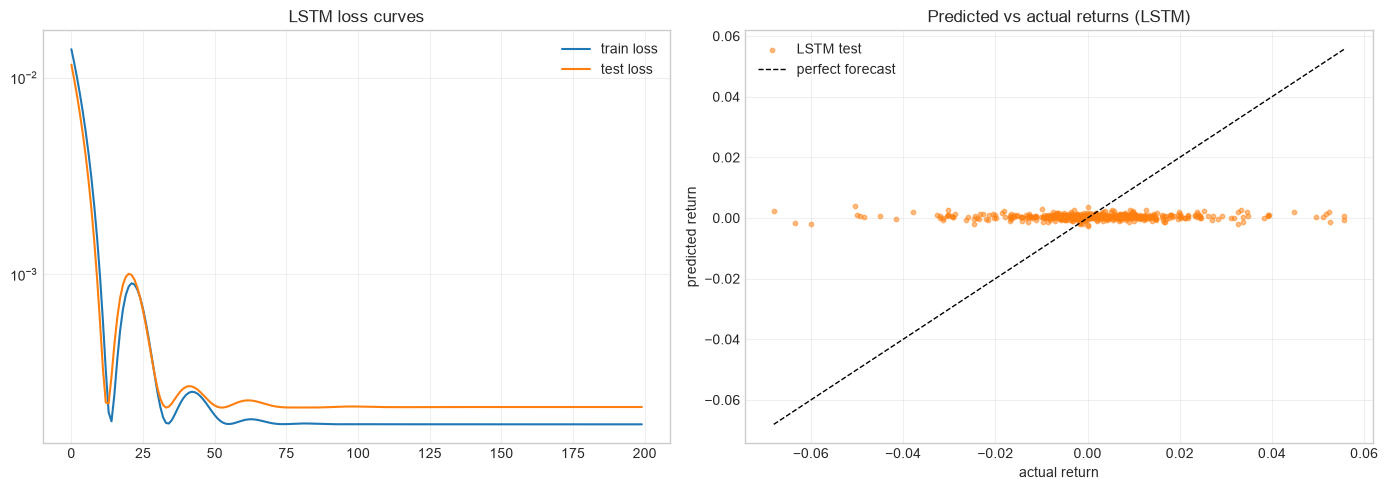

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='train loss')
axes[0].plot(test_losses, label='test loss')
axes[0].set_yscale('log')
axes[0].set_title('LSTM loss curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_seq[:500], lstm_test_pred[:500], s=10, alpha=0.5, label='LSTM test', color='tab:orange')
line = np.linspace(np.min(y_test_seq), np.max(y_test_seq), 200)
axes[1].plot(line, line, color='black', linestyle='--', lw=1, label='perfect forecast')
axes[1].set_title('Predicted vs actual returns (LSTM)')
axes[1].set_xlabel('actual return')
axes[1].set_ylabel('predicted return')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


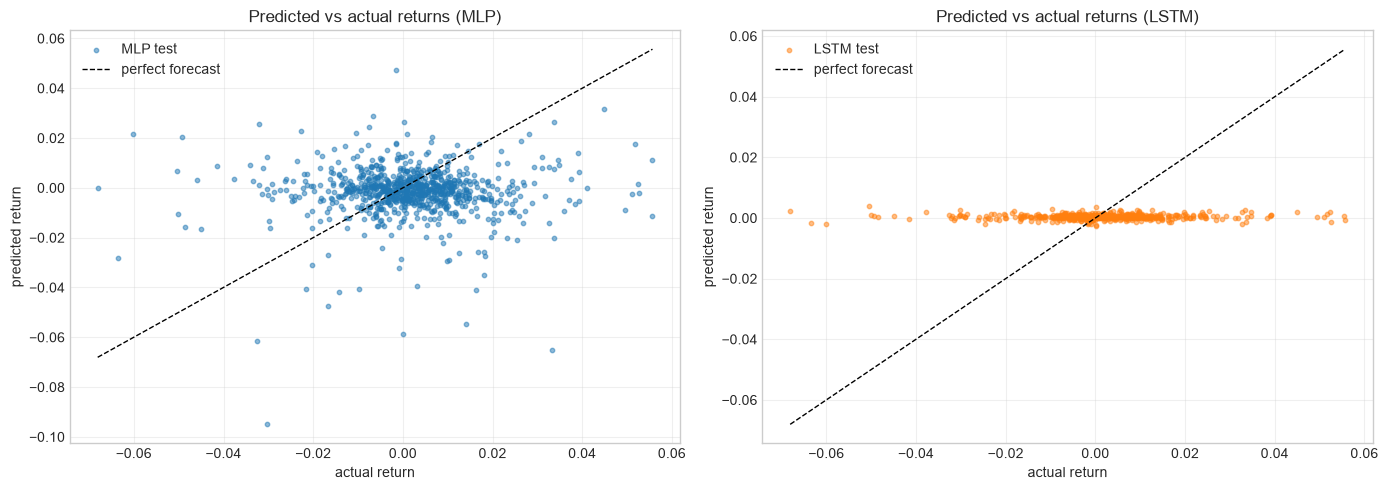

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, mlp_test_pred, alpha=0.5, s=10, label='MLP test', color='tab:blue')
line = np.linspace(np.min(y_test), np.max(y_test), 200)
axes[0].plot(line, line, color='black', linestyle='--', lw=1, label='perfect forecast')
axes[0].set_title('Predicted vs actual returns (MLP)')
axes[0].set_xlabel('actual return')
axes[0].set_ylabel('predicted return')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_seq[:500], lstm_test_pred[:500], s=10, alpha=0.5, label='LSTM test', color='tab:orange')
axes[1].plot(line, line, color='black', linestyle='--', lw=1, label='perfect forecast')
axes[1].set_title('Predicted vs actual returns (LSTM)')
axes[1].set_xlabel('actual return')
axes[1].set_ylabel('predicted return')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
print('=== EGX30 comparison ===')
print(f"MLP test MSE: {mean_squared_error(y_test, mlp_test_pred):.6f} | MAE: {mean_absolute_error(y_test, mlp_test_pred):.6f}")
print(f"LSTM test MSE: {lstm_test_metrics['mse']:.6f} | MAE: {lstm_test_metrics['mae']:.6f}")

if lstm_test_metrics['mse'] < mean_squared_error(y_test, mlp_test_pred):
    verdict = 'The LSTM beat the Day 1 MLP on the EGX30 data.'
else:
    verdict = 'The Day 1 MLP still wins on the EGX30 data.'
print(verdict)


=== EGX30 comparison ===
MLP test MSE: 0.000326 | MAE: 0.012887
LSTM test MSE: 0.000212 | MAE: 0.010312
The LSTM beat the Day 1 MLP on the EGX30 data.


: 

## Interpretation

This comparison keeps the EGX30 data, the feature design, the target, and the test window constant. Only the architecture changes.

The honest result is whichever model has lower out-of-sample error in this setting. On noisy market returns, a more complex sequence model does not automatically outperform a simpler MLP.
